# Tarea 1 - Deep Learning

## DNN para datos tabulares

### Integrantes:
- Lucas Vicuña
- Nombre 2

---

## Objetivo

Construir un dataset tabular de gran escala (>2M registros) y entrenar una red neuronal profunda para un problema de clasificación binaria.

In [1]:
# Ejecutar solo una vez
import install

Instalando numpy...
Instalando pandas...
Instalando requests...
Instalando scikit-learn...
Instalando matplotlib...
Instalando jupyter...
Instalando keras-tuner...
Instalación completa


In [2]:
from libs import *

from data.dataset_builder import build_dataset
from data.preprocessing import preprocess_data
from data.fetch_api import fetch_weather_data_multi

from utils.logger import log_model_summary

from models.dnn_model import build_model

import keras_tuner as kt
from models.automl_model import build_model_tuner

from models.dnn_model import build_model
from utils.logger import log_model_summary, log_dict_to_excel

## Obtención de datos

Se utiliza la API de Open-Meteo para obtener datos climáticos históricos.
Estos datos serán utilizados para construir un dataset de gran escala mediante técnicas de data augmentation.

In [3]:
fetch_weather_data_multi()

[DEBUG] 18:56:48 - === DESCARGA POR LOTES ===
📂 Continuando descarga...
⏩ Saltando Santiago (ya descargada)
⏩ Saltando Buenos Aires (ya descargada)
⏩ Saltando Lima (ya descargada)
⏩ Saltando Bogotá (ya descargada)
⏩ Saltando Mexico City (ya descargada)
⏩ Saltando New York (ya descargada)
⏩ Saltando Los Angeles (ya descargada)
⏩ Saltando Toronto (ya descargada)
⏩ Saltando Chicago (ya descargada)
⏩ Saltando Miami (ya descargada)
⏩ Saltando São Paulo (ya descargada)
⏩ Saltando Rio de Janeiro (ya descargada)
⏩ Saltando Vancouver (ya descargada)
⏩ Saltando Montreal (ya descargada)

🌍 Barcelona
✅ OK (61368, 20)
💾 Guardado incremental

⏳ Pausa 2 min por rate limit...

🌍 Houston
✅ OK (61368, 20)
💾 Guardado incremental
⏩ Saltando Madrid (ya descargada)
⏩ Saltando Paris (ya descargada)
⏩ Saltando London (ya descargada)
⏩ Saltando Berlin (ya descargada)
⏩ Saltando Rome (ya descargada)
⏩ Saltando Lisbon (ya descargada)
⏩ Saltando Amsterdam (ya descargada)
⏩ Saltando Vienna (ya descargada)

🌍 Barce

## Construcción del dataset

Se amplía el dataset original mediante replicación y adición de ruido para alcanzar el volumen requerido.

In [4]:
build_dataset()

[DEBUG] 20:29:35 - === CONSTRUCCIÓN DATASET FINAL ===
[DEBUG] 20:29:38 - Dataset cargado: (2516088, 20)
[DEBUG] 20:29:38 - Después de dropna: (2516088, 20)
[DEBUG] 20:29:38 - Distribución target:
[DEBUG] 20:29:38 - target
0    0.843789
1    0.156211
Name: proportion, dtype: float64
[DEBUG] 20:29:51 - Log guardado en outputs/logs/dataset_log.xlsx
[DEBUG] 20:29:51 - Resumen final:
[DEBUG] 20:29:51 - Filas
        → 2516088
[DEBUG] 20:29:51 - Columnas
        → 21
[DEBUG] 20:29:51 - Ciudades
        → 40
[DEBUG] 20:29:51 - Dataset guardado en outputs/datasets/big_dataset.csv


In [5]:
df = pd.read_csv("outputs/datasets/big_dataset.csv")

print("==== VALIDACIÓN FINAL ====")

print("Shape:", df.shape)
print("Features:", df.shape[1])
print("Ciudades:", df["city"].nunique())

print("\nDistribución target:")
print(df["target"].value_counts(normalize=True))

==== VALIDACIÓN FINAL ====
Shape: (2516088, 21)
Features: 21
Ciudades: 40

Distribución target:
target
0    0.843789
1    0.156211
Name: proportion, dtype: float64


## Preprocesamiento

Se realiza:
- Creación de variable objetivo (lluvia/no lluvia)
- Normalización
- División en entrenamiento, validación y test

In [5]:
X_train, X_val, X_test, y_train, y_val, y_test = preprocess_data()

[DEBUG] 19:46:05 - === INICIO PREPROCESAMIENTO ===
[DEBUG] 19:46:07 - Dataset cargado
        → (2805120, 17)
[DEBUG] 19:46:07 - Creando nuevas features...
[DEBUG] 19:46:07 - Features nuevas agregadas
        → ['time', 'temperature_2m', 'relative_humidity_2m', 'dew_point_2m', 'apparent_temperature', 'precipitation', 'rain', 'snowfall', 'cloudcover', 'cloudcover_low', 'cloudcover_mid', 'cloudcover_high', 'surface_pressure', 'windspeed_10m', 'winddirection_10m', 'shortwave_radiation', 'et0_fao_evapotranspiration', 'temp_range', 'wind_effect']
[DEBUG] 19:46:07 - Creando variable objetivo (target)
[DEBUG] 19:46:07 - Distribución del target
[DEBUG] 19:46:07 - Balance de clases
        → target
0    0.950234
1    0.049766
Name: proportion, dtype: float64
[DEBUG] 19:46:07 - Correlaciones (top 5)
[DEBUG] 19:46:07 - Correlación (sample)
[DEBUG] 19:46:07 -                             temperature_2m  relative_humidity_2m  \
temperature_2m                    1.000000             -0.747584   
rela

# Modelo

In [6]:
input_dim = X_train.shape[1]

model = build_model(input_dim)

model.summary()

# 🔥 guardar summary del modelo
log_model_summary(model)

# 🔥 guardar config básica
log_dict_to_excel({
    "input_dim": input_dim,
    "params": model.count_params(),
    "optimizer": "adam",
    "loss": "binary_crossentropy"
}, filename="model_config.xlsx")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │           2,432 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 12,801 (50.00 KB)

 Trainable params: 12,801 (50.00 KB)

 Non-trainable params: 0 (0.00 B)

[DEBUG] 19:46:10 - Model summary guardado
[DEBUG] 19:46:10 - Log guardado en outputs/logs/model_config.xlsx


# Entrenamiento

In [7]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=256,
    verbose=1
)

# guardar historial
import pandas as pd
pd.DataFrame(history.history).to_excel("outputs/logs/training_log.xlsx", index=False)

# evaluación
loss, acc = model.evaluate(X_test, y_test)

log_dict_to_excel({
    "test_loss": loss,
    "test_accuracy": acc,
    "epochs": 15,
    "batch_size": 256
}, filename="model_results.xlsx")

Epoch 1/15
8766/8766 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step - accuracy: 0.9902 - loss: 0.0233 - val_accuracy: 1.0000 - val_loss: 3.6492e-09
Epoch 2/15
8766/8766 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step - accuracy: 1.0000 - loss: 5.3705e-06 - val_accuracy: 1.0000 - val_loss: 6.6992e-10
Epoch 3/15
8766/8766 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step - accuracy: 1.0000 - loss: 8.8357e-06 - val_accuracy: 1.0000 - val_loss: 1.5826e-14
Epoch 4/15
8766/8766 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step - accuracy: 1.0000 - loss: 1.6717e-08 - val_accuracy: 1.0000 - val_loss: 8.5170e-16
Epoch 5/15
8766/8766 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step - accuracy: 1.0000 - loss: 6.1089e-09 - val_accuracy: 1.0000 - val_loss: 8.7798e-19
Epoch 6/15
8766/8766 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step - accuracy: 1.0000 - loss: 8.0867e-11 - val_accuracy: 1.0000 - val_loss: 2.6059e-20
Epoch 7/15
8766/8766 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step - accuracy: 1.0000 - loss: 7.0137e-11 - val_accuracy: 1.0000 - val_loss: 6.8927e-20
Epoch 8/15
8766/8766 ━━━━━━━━━━━━━━

# Grafico

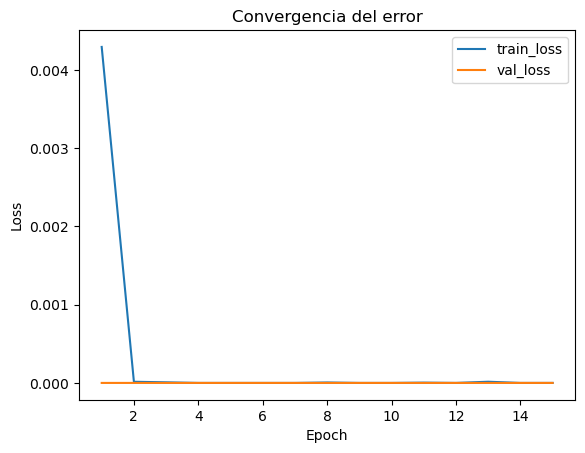

In [8]:
# -------------------------
# 📊 DATAFRAME DEL HISTORIAL
# -------------------------
df_loss = pd.DataFrame({
    "epoch": range(1, len(history.history['loss']) + 1),
    "train_loss": history.history['loss'],
    "val_loss": history.history['val_loss']
})

# guardar datos
df_loss.to_excel("outputs/logs/loss_history.xlsx", index=False)

# -------------------------
# 📈 GRAFICO LOSS
# -------------------------
plt.figure()

plt.plot(df_loss["epoch"], df_loss["train_loss"], label='train_loss')
plt.plot(df_loss["epoch"], df_loss["val_loss"], label='val_loss')

plt.title("Convergencia del error")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# guardar imagen
plt.savefig("outputs/plots/loss.png")

plt.show()

## ACCURACY

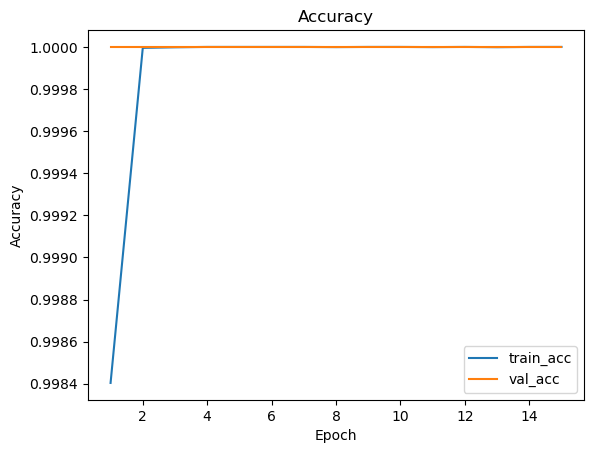

In [9]:
df_acc = pd.DataFrame({
    "epoch": range(1, len(history.history['accuracy']) + 1),
    "train_acc": history.history['accuracy'],
    "val_acc": history.history['val_accuracy']
})

df_acc.to_excel("outputs/logs/accuracy_history.xlsx", index=False)

plt.figure()

plt.plot(df_acc["epoch"], df_acc["train_acc"], label='train_acc')
plt.plot(df_acc["epoch"], df_acc["val_acc"], label='val_acc')

plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.savefig("outputs/plots/accuracy.png")

plt.show()

# AutoML

In [10]:
input_dim = X_train.shape[1]

tuner = kt.RandomSearch(
    lambda hp: build_model_tuner(hp, input_dim),
    objective='val_accuracy',
    max_trials=5,
    executions_per_trial=1,
    directory='outputs/automl',
    project_name='weather_dnn'
)

tuner.search(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=256
)

Reloading Tuner from outputs/automl\weather_dnn\tuner0.json


# OBTENER MEJOR MODELO

In [11]:
best_model = tuner.get_best_models(num_models=1)[0]

best_model.summary()

C:\Users\Alpacachino\anaconda3\Lib\site-packages\keras\src\saving\saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 256)                 │           4,864 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 96)                  │          24,672 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 96)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              97 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 29,633 (115.75 KB)

 Trainable params: 29,633 (115.75 KB)

 Non-trainable params: 0 (0.00 B)

# ENTRENAR MEJOR MODELO

In [12]:
history_automl = best_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=256
)

Epoch 1/15
8766/8766 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step - accuracy: 1.0000 - loss: 6.0222e-04 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/15
8766/8766 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step - accuracy: 1.0000 - loss: 3.3356e-04 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/15
8766/8766 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step - accuracy: 1.0000 - loss: 8.8665e-04 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/15
8766/8766 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step - accuracy: 1.0000 - loss: 4.7229e-04 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/15
8766/8766 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step - accuracy: 1.0000 - loss: 6.9808e-20 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 6/15
8766/8766 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step - accuracy: 1.0000 - loss: 8.9248e-05 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 7/15
8766/8766 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step - accuracy: 1.0000 - loss: 1.6220e-35 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 8/15
8766/8766 ━━━━━━

In [13]:
# historial
pd.DataFrame(history_automl.history).to_excel(
    "outputs/logs/automl_training_log.xlsx",
    index=False
)

# evaluación
loss_auto, acc_auto = best_model.evaluate(X_test, y_test)

log_dict_to_excel({
    "model": "AutoML",
    "test_loss": loss_auto,
    "test_accuracy": acc_auto
}, filename="automl_results.xlsx")

8766/8766 ━━━━━━━━━━━━━━━━━━━━ 5s 602us/step - accuracy: 1.0000 - loss: 0.0000e+00
[DEBUG] 19:51:36 - Log guardado en outputs/logs/automl_results.xlsx


# COMPARACIÓN

In [14]:
manual = pd.read_excel("outputs/logs/model_results.xlsx")
automl = pd.read_excel("outputs/logs/automl_results.xlsx")

comparison = pd.concat([manual, automl], ignore_index=True)

comparison.to_excel("outputs/logs/comparison.xlsx", index=False)

comparison

,test_loss,test_accuracy,epochs,batch_size,model
0,1.004980e-19,1,15.0,256.0,NaN
1,5.295151e-27,1,15.0,256.0,NaN
2,1.607307e-25,1,15.0,256.0,NaN
3,1.346625e-23,1,15.0,256.0,NaN
4,2.380665e-20,1,15.0,256.0,NaN
5,2.010801e-18,1,15.0,256.0,NaN
6,0.000000e+00,1,NaN,NaN,AutoML


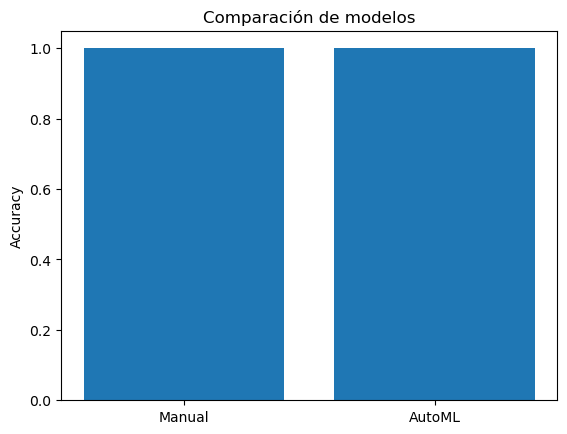

In [15]:
labels = ["Manual", "AutoML"]
accuracies = [manual["test_accuracy"][0], automl["test_accuracy"][0]]

plt.bar(labels, accuracies)

plt.title("Comparación de modelos")
plt.ylabel("Accuracy")

plt.savefig("outputs/plots/comparison.png")

plt.show()

In [6]:
def menu():
    debug("Iniciando sistema")

    while True:
        print("\n=== MENU PRINCIPAL ===")
        print("1. Descargar datos desde API")
        print("2. Construir dataset grande")
        print("3. Preprocesar datos")
        print("4. Salir")

        opcion = input("Selecciona opción: ")

        if opcion == "1":
            debug("Opción 1 seleccionada")
            fetch_weather_data()

        elif opcion == "2":
            debug("Opción 2 seleccionada")
            build_dataset()

        elif opcion == "3":
            debug("Opción 3 seleccionada")
            preprocess_data()

        elif opcion == "4":
            debug("Saliendo del programa")
            break

        else:
            print("Opción inválida")

if __name__ == "__main__":
    menu()

[DEBUG] 16:23:10 - Iniciando sistema

=== MENU PRINCIPAL ===
1. Descargar datos desde API
2. Construir dataset grande
3. Preprocesar datos
4. Salir


Selecciona opción:  1


[DEBUG] 16:23:14 - Opción 1 seleccionada


NameError: name 'debug' is not defined